Genz Slag Evolution Analysis

#library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
Genz = pd.read_csv(r"genz_slang_usage_2020_2025.csv")

In [4]:
# Read first 5 rows
print(Genz)

        record_id            timestamp    slang_term term_category  \
0               0  2020-01-01 01:23:17          simp        insult   
1               1  2020-01-01 03:21:59          simp        insult   
2               2  2020-01-01 05:31:01    vibe check        social   
3               3  2020-01-01 05:35:30        no cap      emphasis   
4               4  2020-01-01 06:39:57        no cap      emphasis   
...           ...                  ...           ...           ...   
535391     535391  2025-12-31 23:26:53        cooked      reaction   
535392     535392  2025-12-31 23:29:56  looksmaxxing    appearance   
535393     535393  2025-12-31 23:37:40          aura      identity   
535394     535394  2025-12-31 23:42:39        cooked      reaction   
535395     535395  2025-12-31 23:52:04  looksmaxxing    appearance   

                                    term_meaning origin_platform  \
0       someone overly devoted to another person          Reddit   
1       someone overly 

In [5]:
# Read first 5 rows
Genz.head(10)

,record_id,timestamp,slang_term,term_category,term_meaning,origin_platform,usage_platform,region,user_id,user_age_group,...,intensity_score,sentiment,sentiment_score,ironic_usage,likes,shares,comments,virality_score,is_viral,days_since_emergence
0,0,2020-01-01 01:23:17,simp,insult,someone overly devoted to another person,Reddit,Twitter,California,user_019223,25-30,...,0.603,negative,-0.740,False,18,2,5,0.004,False,153
1,1,2020-01-01 03:21:59,simp,insult,someone overly devoted to another person,Reddit,Twitter,Texas,user_497341,13-17,...,0.603,negative,-0.978,False,24,1,2,0.004,False,153
2,2,2020-01-01 05:31:01,vibe check,social,checking someone's mood/energy,TikTok,TikTok,Canada,user_323563,31-40,...,0.552,positive,0.384,False,121,1,0,0.013,False,92
3,3,2020-01-01 05:35:30,no cap,emphasis,"no lie, for real",Twitter,Twitter,Arizona,user_244857,18-24,...,0.551,neutral,0.167,False,47,2,1,0.006,False,214
4,4,2020-01-01 06:39:57,no cap,emphasis,"no lie, for real",Twitter,Instagram,Arizona,user_421848,13-17,...,0.551,positive,0.874,False,18,0,14,0.006,False,214
5,5,2020-01-01 06:51:27,vibe check,social,checking someone's mood/energy,TikTok,TikTok,Germany,user_456630,18-24,...,0.552,positive,0.925,True,144,1,8,0.017,False,92
6,6,2020-01-01 06:54:44,vibe check,social,checking someone's mood/energy,TikTok,Instagram,Michigan,user_400259,13-17,...,0.552,negative,-0.417,False,149,2,5,0.017,False,92
7,7,2020-01-01 07:13:32,hits different,emotion,affects you in a unique way,Twitter,Twitter,Texas,user_198862,25-30,...,0.280,negative,-0.822,True,2,0,5,0.002,False,61
8,8,2020-01-01 07:18:31,bussin,approval,"really good, especially food",TikTok,YouTube,California,user_044389,18-24,...,0.100,positive,0.696,False,18,0,0,0.002,False,0
9,9,2020-01-01 07:40:01,no cap,emphasis,"no lie, for real",Twitter,Twitter,New York,user_233854,31-40,...,0.551,positive,0.305,False,3,1,2,0.001,False,214


In [6]:
Genz.tail(10)

,record_id,timestamp,slang_term,term_category,term_meaning,origin_platform,usage_platform,region,user_id,user_age_group,...,intensity_score,sentiment,sentiment_score,ironic_usage,likes,shares,comments,virality_score,is_viral,days_since_emergence
535386,535386,2025-12-31 22:59:11,looksmaxxing,appearance,maximizing physical appearance,YouTube,TikTok,UK,user_453971,25-30,...,0.650,positive,0.902,False,42,0,37,0.015,False,639
535387,535387,2025-12-31 22:59:44,yapping,behavior,talking too much,TikTok,TikTok,Australia,user_494308,25-30,...,0.519,positive,0.537,False,73,3,6,0.011,False,730
535388,535388,2025-12-31 23:04:50,yapping,behavior,talking too much,TikTok,Twitter,Ohio,user_404881,25-30,...,0.519,negative,-0.935,False,10,0,0,0.001,False,730
535389,535389,2025-12-31 23:05:38,aura,identity,personal energy/presence points,TikTok,TikTok,Florida,user_011640,31-40,...,0.579,neutral,-0.039,False,7,0,10,0.004,False,578
535390,535390,2025-12-31 23:26:49,looksmaxxing,appearance,maximizing physical appearance,YouTube,Twitter,Texas,user_012929,18-24,...,0.650,neutral,-0.174,False,51,0,8,0.008,False,639
535391,535391,2025-12-31 23:26:53,cooked,reaction,"done for, ruined",TikTok,Reddit,Georgia,user_032892,18-24,...,0.588,neutral,-0.265,True,16,4,4,0.005,False,699
535392,535392,2025-12-31 23:29:56,looksmaxxing,appearance,maximizing physical appearance,YouTube,YouTube,India,user_172355,31-40,...,0.650,positive,0.893,False,1,0,0,0.000,False,639
535393,535393,2025-12-31 23:37:40,aura,identity,personal energy/presence points,TikTok,TikTok,UK,user_208644,13-17,...,0.579,neutral,-0.114,False,35,14,0,0.011,False,578
535394,535394,2025-12-31 23:42:39,cooked,reaction,"done for, ruined",TikTok,TikTok,California,user_114038,18-24,...,0.588,neutral,0.161,True,175,4,19,0.025,False,699
535395,535395,2025-12-31 23:52:04,looksmaxxing,appearance,maximizing physical appearance,YouTube,Twitter,UK,user_408264,31-40,...,0.650,positive,0.686,False,43,0,0,0.004,False,639


In [7]:
#shape of Data set
print(f"The Dataset have {Genz.shape[0]} rows & {Genz.shape[1]} columns")

The Dataset have 535396 rows & 22 columns


In [8]:
# Information of Column
Genz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535396 entries, 0 to 535395
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   record_id             535396 non-null  int64  
 1   timestamp             535396 non-null  object 
 2   slang_term            535396 non-null  object 
 3   term_category         535396 non-null  object 
 4   term_meaning          535396 non-null  object 
 5   origin_platform       535396 non-null  object 
 6   usage_platform        535396 non-null  object 
 7   region                535396 non-null  object 
 8   user_id               535396 non-null  object 
 9   user_age_group        535396 non-null  object 
 10  usage_context         535396 non-null  object 
 11  lifecycle_phase       535396 non-null  object 
 12  intensity_score       535396 non-null  float64
 13  sentiment             535396 non-null  object 
 14  sentiment_score       535396 non-null  float64
 15  

In [11]:
for col in Genz.columns:
    print(Genz[col].unique())
    print("--"*50)

[     0      1      2 ... 535393 535394 535395]
----------------------------------------------------------------------------------------------------
['2020-01-01 01:23:17' '2020-01-01 03:21:59' '2020-01-01 05:31:01' ...
 '2025-12-31 23:37:40' '2025-12-31 23:42:39' '2025-12-31 23:52:04']
----------------------------------------------------------------------------------------------------
['simp' 'vibe check' 'no cap' 'hits different' 'bussin' 'slaps' 'periodt'
 'rent free' 'main character' 'slay' 'based' 'caught in 4k'
 'understood the assignment' 'sheesh' 'its giving' 'cheugy' 'gaslighting'
 'ate' 'valid' 'mid' 'snatched' 'touch grass' 'rizz' 'NPC' 'ick'
 'unhinged' 'delulu' 'era' 'ohio' 'beige flag' 'sigma' 'skibidi'
 'girl dinner' 'brain rot' 'girl math' 'fanum tax' 'Roman Empire' 'gyatt'
 'yapping' 'cooked' 'mewing' 'looksmaxxing' 'brat' 'aura' 'very mindful'
 'demure']
----------------------------------------------------------------------------------------------------
['insult' 'soc

In [12]:
Genz.isnull().sum()

record_id               0
timestamp               0
slang_term              0
term_category           0
term_meaning            0
origin_platform         0
usage_platform          0
region                  0
user_id                 0
user_age_group          0
usage_context           0
lifecycle_phase         0
intensity_score         0
sentiment               0
sentiment_score         0
ironic_usage            0
likes                   0
shares                  0
comments                0
virality_score          0
is_viral                0
days_since_emergence    0
dtype: int64

In [13]:
Genz["timestamp"] = pd.to_datetime(Genz["timestamp"],errors='coerce')


In [16]:
Genz

,record_id,timestamp,slang_term,term_category,term_meaning,origin_platform,usage_platform,region,user_id,user_age_group,...,intensity_score,sentiment,sentiment_score,ironic_usage,likes,shares,comments,virality_score,is_viral,days_since_emergence
0,0,2020-01-01 01:23:17,simp,insult,someone overly devoted to another person,Reddit,Twitter,California,user_019223,25-30,...,0.603,negative,-0.740,False,18,2,5,0.004,False,153
1,1,2020-01-01 03:21:59,simp,insult,someone overly devoted to another person,Reddit,Twitter,Texas,user_497341,13-17,...,0.603,negative,-0.978,False,24,1,2,0.004,False,153
2,2,2020-01-01 05:31:01,vibe check,social,checking someone's mood/energy,TikTok,TikTok,Canada,user_323563,31-40,...,0.552,positive,0.384,False,121,1,0,0.013,False,92
3,3,2020-01-01 05:35:30,no cap,emphasis,"no lie, for real",Twitter,Twitter,Arizona,user_244857,18-24,...,0.551,neutral,0.167,False,47,2,1,0.006,False,214
4,4,2020-01-01 06:39:57,no cap,emphasis,"no lie, for real",Twitter,Instagram,Arizona,user_421848,13-17,...,0.551,positive,0.874,False,18,0,14,0.006,False,214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535391,535391,2025-12-31 23:26:53,cooked,reaction,"done for, ruined",TikTok,Reddit,Georgia,user_032892,18-24,...,0.588,neutral,-0.265,True,16,4,4,0.005,False,699
535392,535392,2025-12-31 23:29:56,looksmaxxing,appearance,maximizing physical appearance,YouTube,YouTube,India,user_172355,31-40,...,0.650,positive,0.893,False,1,0,0,0.000,False,639
535393,535393,2025-12-31 23:37:40,aura,identity,personal energy/presence points,TikTok,TikTok,UK,user_208644,13-17,...,0.579,neutral,-0.114,False,35,14,0,0.011,False,578
535394,535394,2025-12-31 23:42:39,cooked,reaction,"done for, ruined",TikTok,TikTok,California,user_114038,18-24,...,0.588,neutral,0.161,True,175,4,19,0.025,False,699


In [15]:
Genz.describe().T

,count,mean,min,25%,50%,75%,max,std
record_id,535396.0,267697.5,0.0,133848.75,267697.5,401546.25,535395.0,154555.656698
timestamp,535396,2023-02-15 18:27:32.009215744,2020-01-01 01:23:17,2021-11-24 15:32:47,2023-03-22 15:05:47,2024-05-17 16:25:32.500000,2025-12-31 23:52:04,NaN
intensity_score,535396.0,0.656799,0.09,0.505,0.687,0.844,1.0,0.229561
sentiment_score,535396.0,0.175213,-1.0,-0.212,0.246,0.633,1.0,0.542696
likes,535396.0,61.483362,0.0,9.0,28.0,71.0,35200.0,227.016926
shares,535396.0,3.298273,0.0,0.0,1.0,4.0,3990.0,16.171007
comments,535396.0,7.009772,0.0,1.0,3.0,8.0,6121.0,30.638933
virality_score,535396.0,0.009765,0.0,0.003,0.006,0.012,1.0,0.022437
days_since_emergence,535396.0,474.526909,0.0,261.0,446.0,655.0,1428.0,269.419917


In [17]:
Genz.describe(include="object").T

,count,unique,top,freq
slang_term,535396,46,slay,19004
term_category,535396,17,approval,106901
term_meaning,535396,46,doing something exceptionally well,19004
origin_platform,535396,6,TikTok,278028
usage_platform,535396,7,TikTok,214638
region,535396,22,California,64047
user_id,535396,328571,user_466578,8
user_age_group,535396,5,18-24,187264
usage_context,535396,17,criticism,31758
lifecycle_phase,535396,4,declining,203431


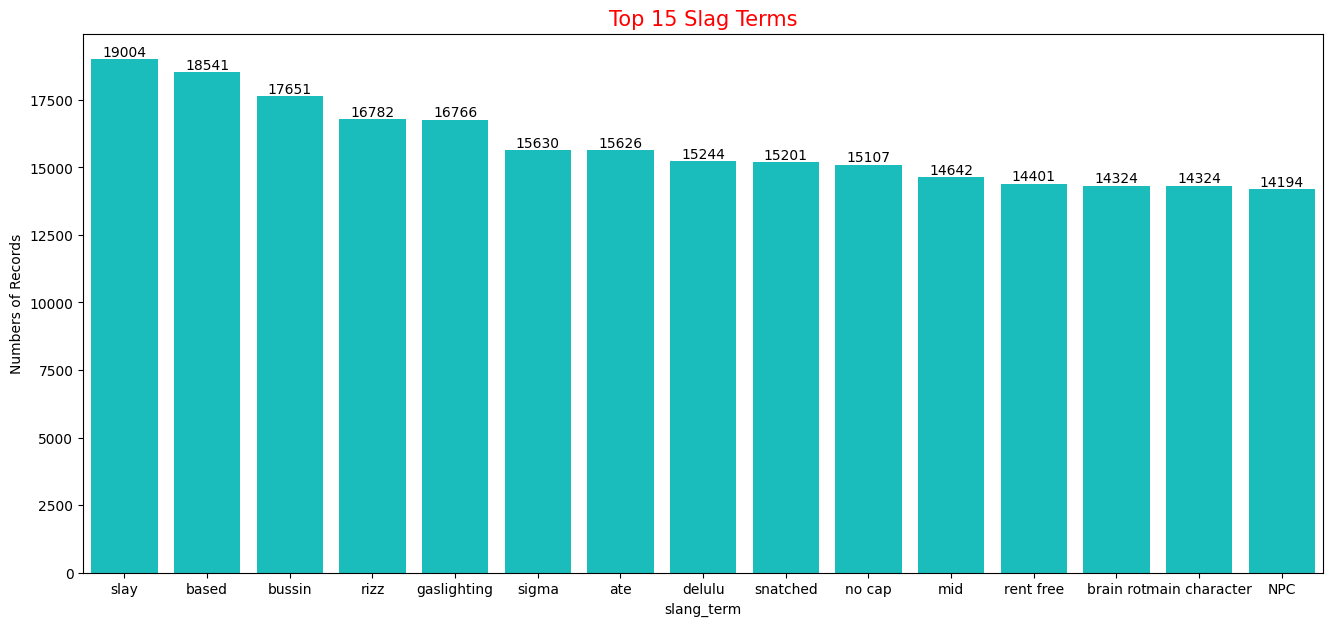

In [18]:
Slag_Term = (Genz["slang_term"].value_counts().reset_index().head(15))
plt.figure(figsize=(16,7))
ax = sns.barplot(x = 'slang_term',y = 'count' , data= Slag_Term,color ="#00d8d6")
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Top 15 Slag Terms",fontsize = 15, color = "Red")
plt.ylabel("Numbers of Records")
plt.show()

Slang Term by Categories

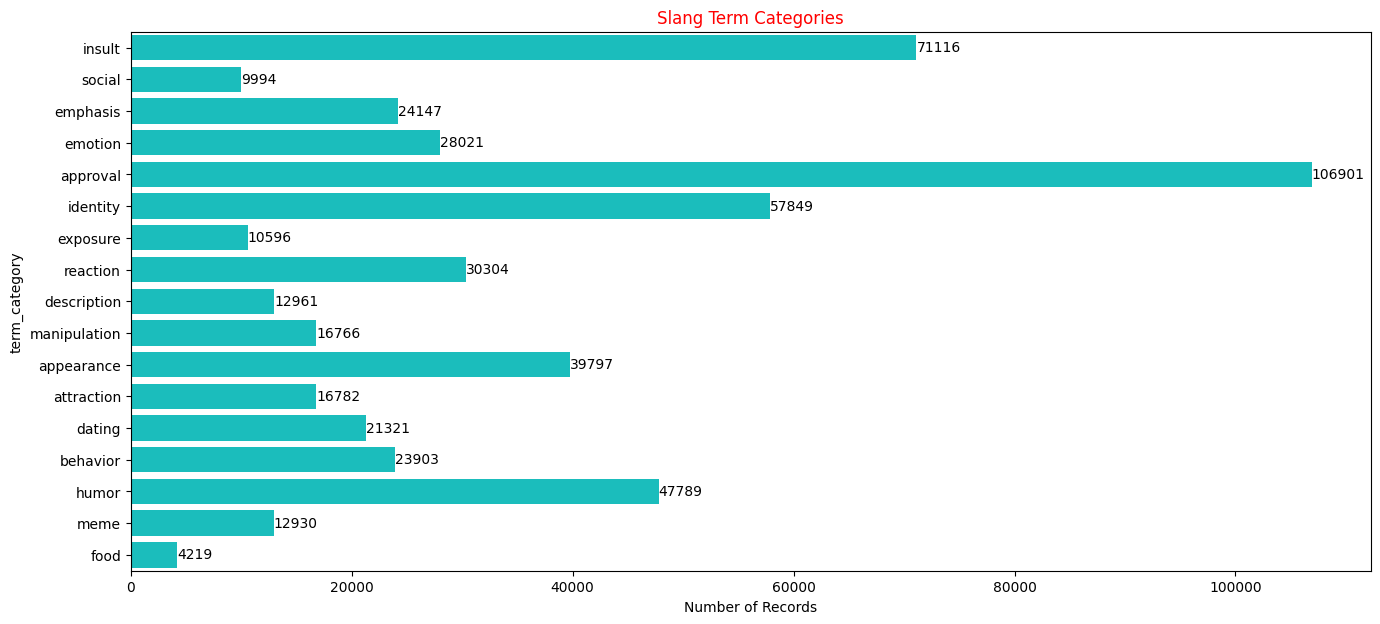

In [19]:
plt.figure(figsize=(16,7))
ax = sns.countplot(y="term_category", data= Genz,color="#00d8d6")
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Slang Term Categories", fontsize = 12, color = "red")
plt.xlabel("Number of Records")
plt.show()

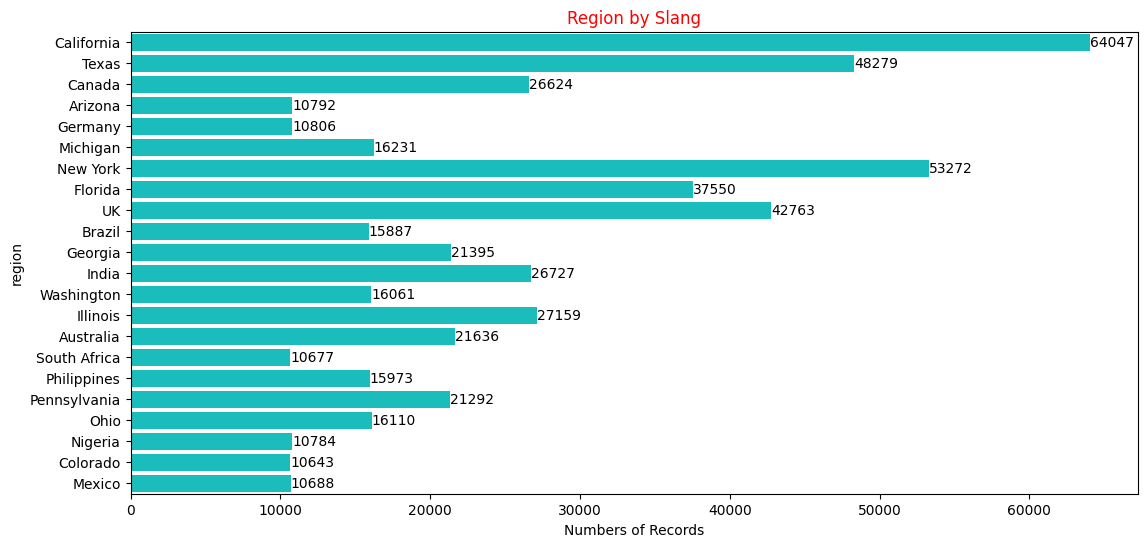

In [21]:
#Region by Slang
plt.figure(figsize=(13,6))
ax= sns.countplot(y="region", data=Genz,color="#00d8d6")

for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Region by Slang", fontsize =12, color = "red")
plt.xlabel("Numbers of Records")
plt.show()

Insights

• California leads slang usage, indicating strong influence of pop culture,
social media, and digital trends.
• New York and Texas follow closely, showing high slang adoption in
large, urban and socially active regions.
• UK and Florida show strong engagement, highlighting that slang usage
is not limited to the US only.
• India and Canada have moderate but significant usage, reflecting
growing global exposure to English and internet culture.
• African and Latin American regions (Nigeria, South Africa, Mexico) show
lower counts, suggesting regional language preference or lower dataset
representation.

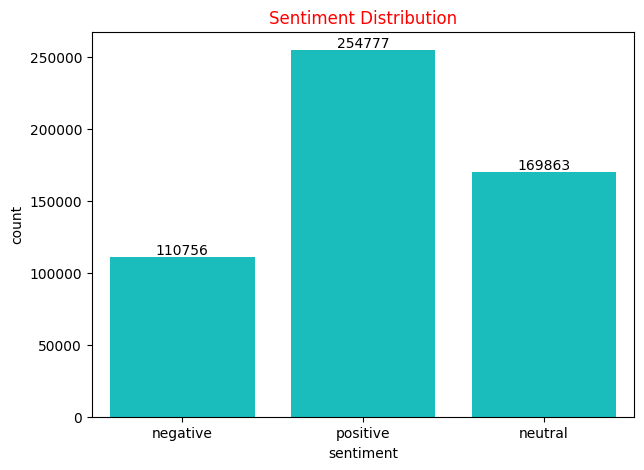

In [23]:
#Sentiment Distribution

plt.figure(figsize=(7,5))
ax = sns.countplot(x = "sentiment", data= Genz, color="#00d8d6")
for bar in ax. containers: 
    plt.bar_label(bar)
plt.title("Sentiment Distribution",fontsize = 12, color = "Red")
plt.show()

Insights
• Positive sentiment dominates the dataset, showing that most slang
usage carries a favorable or expressive tone.
• Neutral sentiment is the second highest, indicating slang is often used
casually without strong emotions.
• Negative sentiment is the lowest, suggesting slang is less commonly
used for criticism or hate compared to fun or expression.

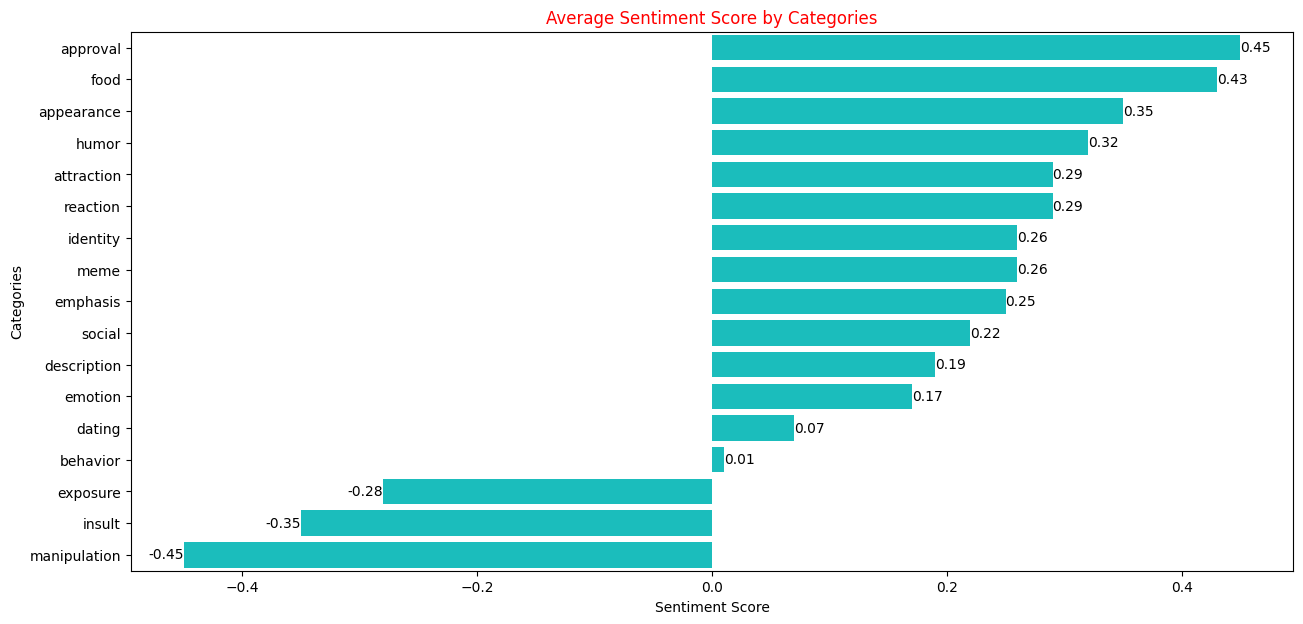

In [24]:
#Sentiment Score by Categories

Avg_Sentiment = (Genz.groupby("term_category") ["sentiment_score"].mean().reset_index().round(2))
Avg_Sentiment = (Avg_Sentiment.sort_values (by="sentiment_score",ascending=False))
plt.figure(figsize=(15,7))
ax = sns.barplot(y = "term_category", x = "sentiment_score", data= Avg_Sentiment, color="#00d8d6")
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Average Sentiment Score by Categories", fontsize =12, color = "Red")
plt.xlabel("Sentiment Score")
plt.ylabel("Categories")
plt.show()

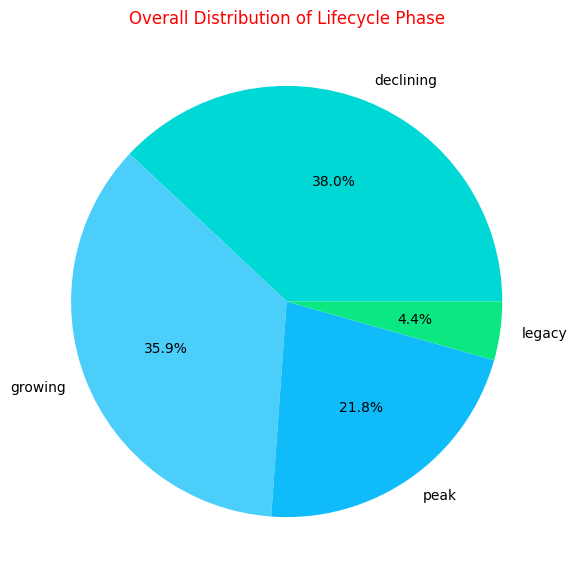

In [25]:
#LifeCycle Phase Distribution
Life_cylcle = Genz["lifecycle_phase"].value_counts()
color = ["#00d8d6","#4bcffa","#0fbcf9","#0be881"]
plt.figure(figsize=(10,7))
plt.pie(Life_cylcle.values, labels=Life_cylcle.index , autopct="%0.1f%%", colors=color)
plt.title("Overall Distribution of Lifecycle Phase", fontsize = 12, color = "Red")
plt.show()

• Declining phase has the highest share (~38%), indicating many slang
terms are losing popularity over time.
• Growing phase is a close second (~36%), showing a strong pipeline of
new or emerging slang.
• Peak phase accounts for ~22%, meaning a smaller portion of slang is
currently at maximum popularity.
• Legacy terms form a very small share (~4%), suggesting only a few
slang words remain relevant long-term.

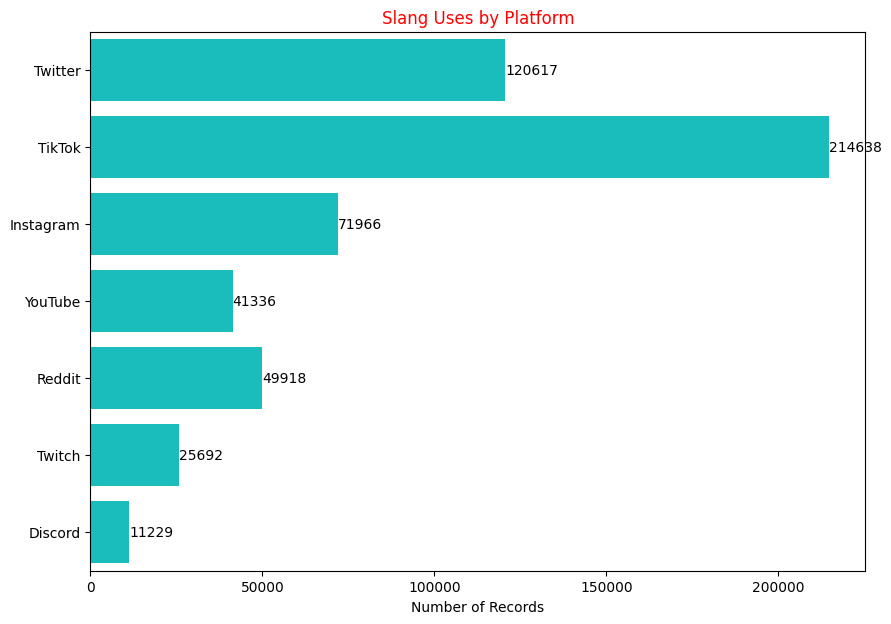

In [26]:
#Uses Platform Distribution

plt.figure(figsize=(10,7))
ax = sns.countplot(y = "usage_platform",data=Genz, color="#00d8d6")

for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Slang Uses by Platform", fontsize =12, color = "Red")
plt.xlabel("Number of Records")
plt.ylabel("")
plt.show()

Insights
• TikTok dominates slang usage, making it the primary driver of new and
viral slang trends.
• Twitter (X) ranks second, showing slang is widely used in short,
conversational, and reactive content.
• Instagram has moderate usage, indicating slang is more common in
captions, reels, and comments than in long-form posts.
• Reddit and YouTube show lower but meaningful usage, suggesting slang
appears mainly in comments and niche communities.
• Discord and Twitch have the lowest counts, likely due to more private or
community-specific conversations.

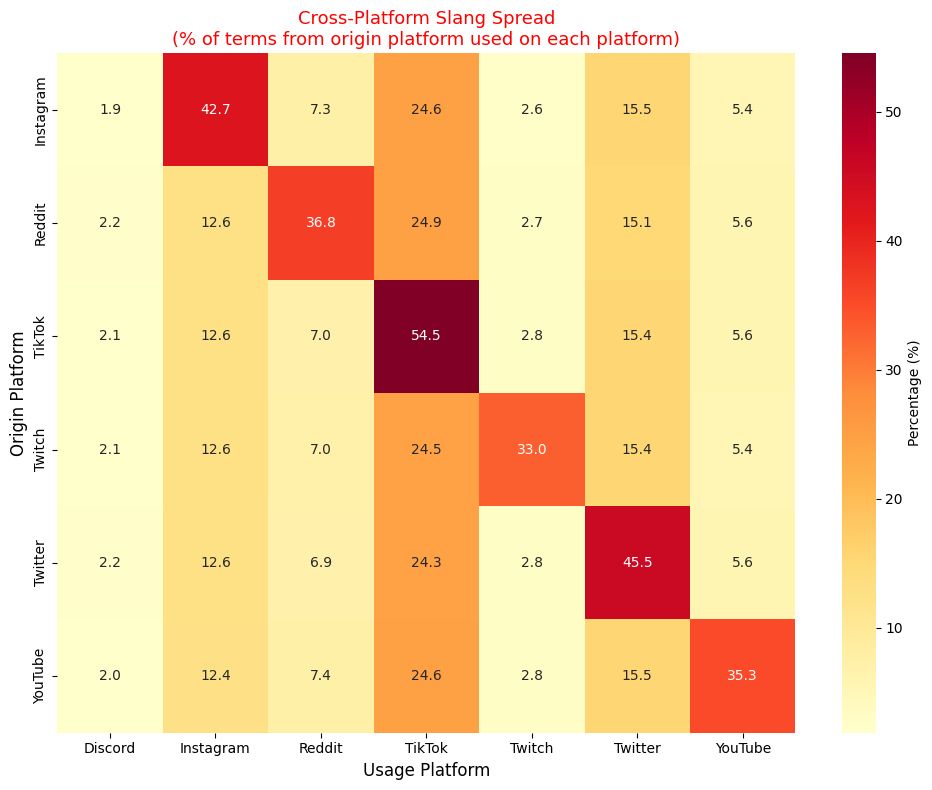

In [27]:


# Create cross-tab matrix (row-wise percentage)
cross_matrix = pd.crosstab(
    Genz['origin_platform'],
    Genz['usage_platform'],
    normalize='index'
) * 100

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cross_matrix,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Percentage (%)'}
)

ax.set_xlabel('Usage Platform', fontsize=12)
ax.set_ylabel('Origin Platform', fontsize=12)
ax.set_title(
    'Cross-Platform Slang Spread\n(% of terms from origin platform used on each platform)',
    fontsize=13,
    color='red'
)

plt.tight_layout()
plt.show()


Insights
• Each platform shows the highest retention on itself, e.g., TikTok →
TikTok (~54%), Twitter → Twitter (~45%), indicating strong platformspecific slang identity.
• TikTok acts as the biggest slang exporter, with a high percentage of itsIn [18]:slang spreading to Instagram, Twitter, and YouTube.
• Instagram and Twitter are major receivers, absorbing slang from
multiple platforms, especially TikTok.
• Reddit-origin slang spreads moderately, mainly to TikTok and Twitter,
showing niche-to-mainstream movement.
• Discord shows minimal cross-platform influence, indicating slang there
remains community-specific.
• YouTube receives slang from almost all platforms, suggesting it acts as
a convergence point rather than an origin.

Text(0, 0.5, 'Numbers of Records')

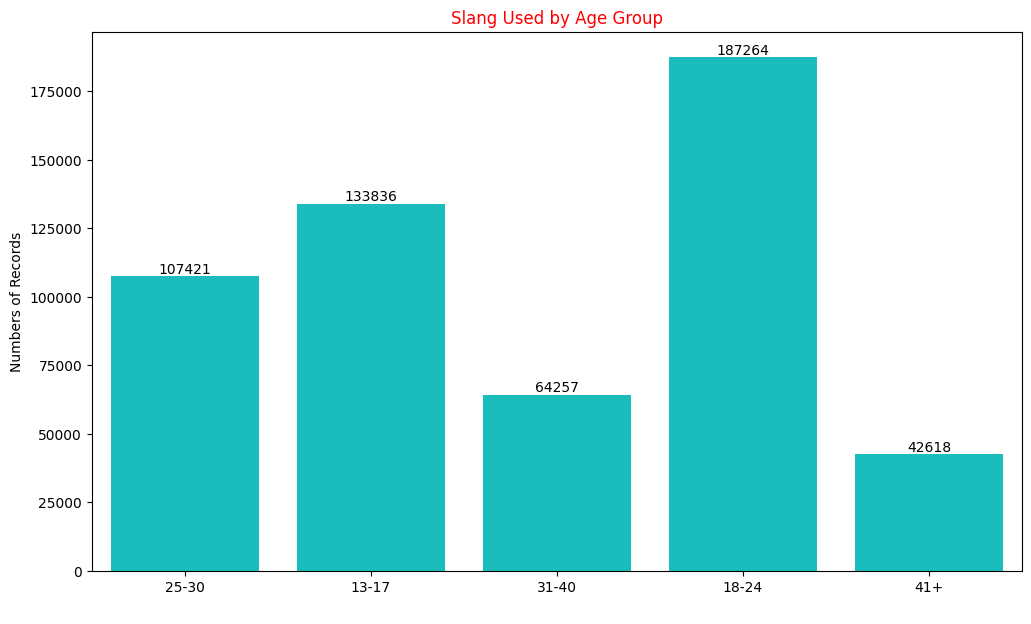

In [28]:
#Slang Used by Age_Group

plt.figure(figsize=(12,7))
ax=sns.countplot(x = "user_age_group",data=Genz,color="#00d8d6")
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Slang Used by Age Group",
fontsize= 12, color = "Red")
plt.xlabel(" ")
plt.ylabel("Numbers of Records")

Insights
• Age group 18–24 shows the highest slang usage, confirming that young
adults are the primary drivers of slang adoption.
• Teenagers (13–17) are the second-highest users, indicating early
adoption and trend experimentation.
• Usage drops significantly after age 30, showing reduced engagement
with evolving slang.
• Age group 25–30 still shows strong usage, acting as a bridge between
Gen Z and older demographics.
• 41+ age group has the lowest slang usage, suggesting preference for
more formal or stable languag

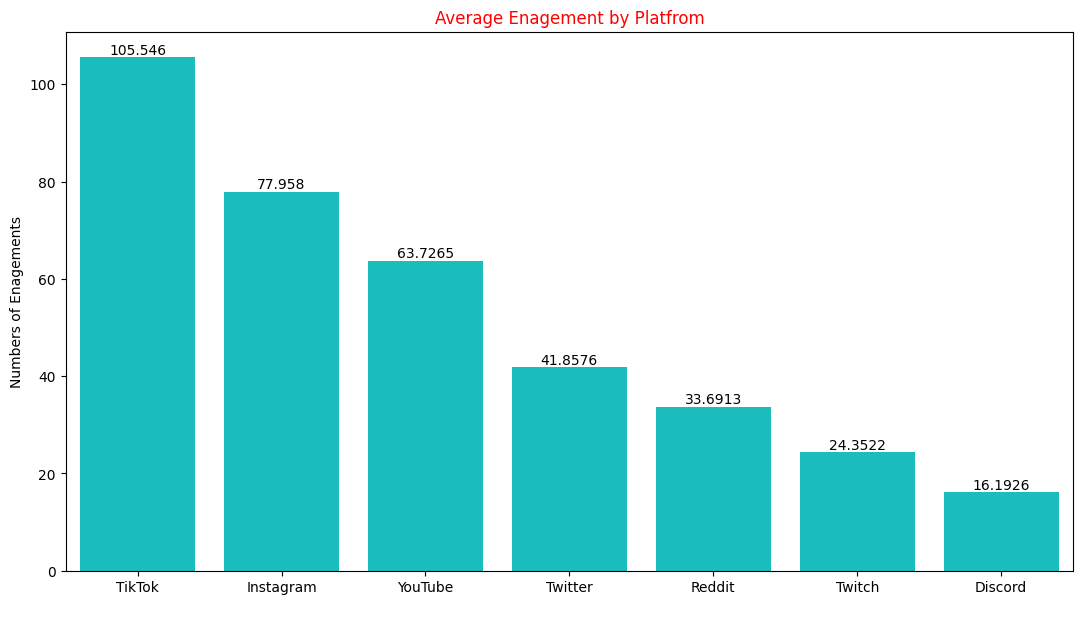

In [29]:
#Avearge Enagement by Platform


Genz["Total_Enagement"] = Genz["likes"]+Genz["comments"]+Genz["shares"]
Platform_Enagement = (Genz.groupby("usage_platform")
["Total_Enagement"].mean().reset_index())
Platform_Enagement = (Platform_Enagement.sort_values(by="Total_Enagement",
ascending=False))
plt.figure(figsize=(13,7))
ax = sns.barplot(x = "usage_platform", y = "Total_Enagement",
data=Platform_Enagement, color="#00d8d6")
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Average Enagement by Platfrom", fontsize = 12, color = "red")
plt.xlabel(" ")
plt.ylabel("Numbers of Enagements")
plt.show()

Insights
• TikTok has the highest average engagement, showing it is the most
interactive and viral platform for slang-related content.
• Instagram ranks second, indicating strong user interaction through
reels, stories, and comments.
• YouTube also shows high engagement, suggesting long-form content
still generates meaningful interaction.
• Twitter (X) has moderate engagement, mainly driven by real-time
discussions and trends.
• Reddit shows lower engagement, but users are more niche and
discussion-focused.
• Twitch and Discord have the lowest engagement, likely due to smaller,
community-based interactions.

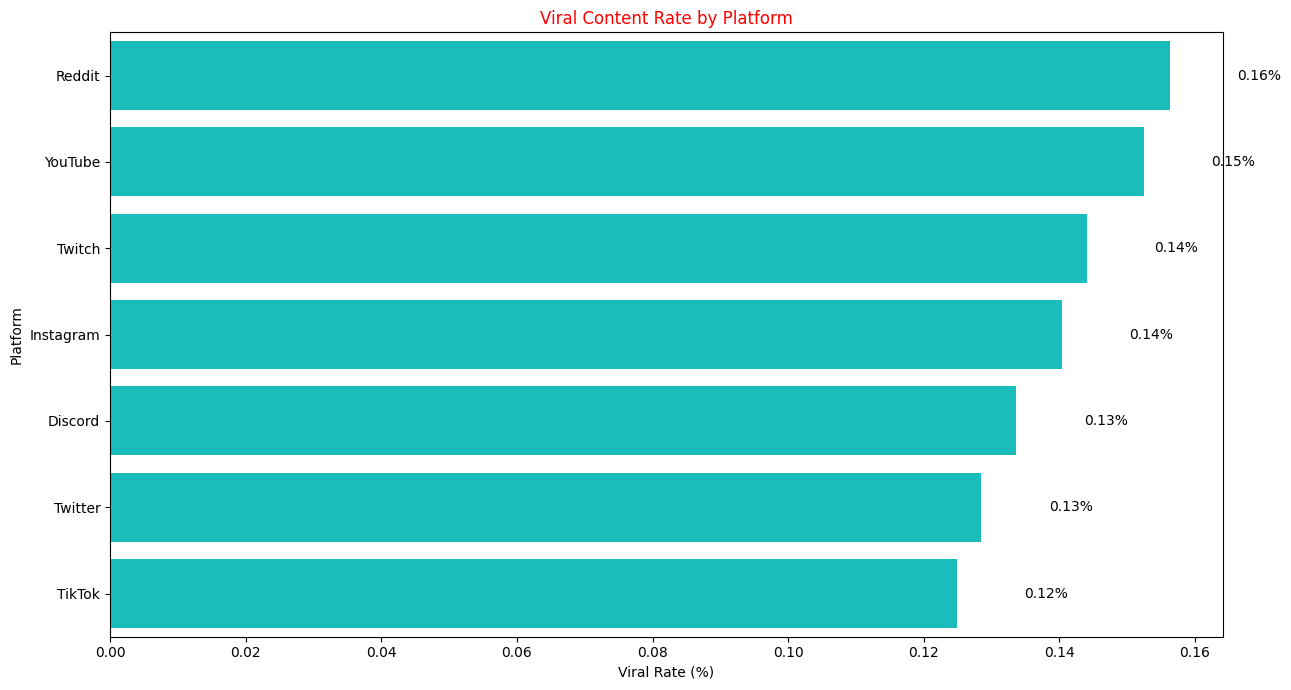

In [31]:
#Viral Content Rate Analysis


viral_by_platform = Genz.groupby('usage_platform')['is_viral'].mean() * 100
viral_by_platform = (viral_by_platform.reset_index().sort_values(by="is_viral",ascending=False))
plt.figure(figsize=(13,7))
ax = sns.barplot(x = "is_viral",y="usage_platform",
data= viral_by_platform,color="#00d8d6")
plt.xlabel("Viral Rate (%)")
plt.ylabel("Platform")
plt.title("Viral Content Rate by Platform", fontsize = 12, color = "Red")
for i, v in enumerate(viral_by_platform["is_viral"]):
    ax.text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
Insights
• Reddit has the highest viral content percentage, indicating that a larger
share of its content gains strong traction within communities.
• YouTube ranks second, showing that fewer but high-impact videos tend
to go viral.
• Instagram and Twitch are close behind, suggesting good virality driven
by reels, clips, and live interactions.
• Discord and Twitter show moderate viral rates, reflecting communityfocused or real-time content rather than mass virality.
• TikTok, despite high engagement volume, has the lowest viral
percentage, meaning virality is competitive due to content saturatio

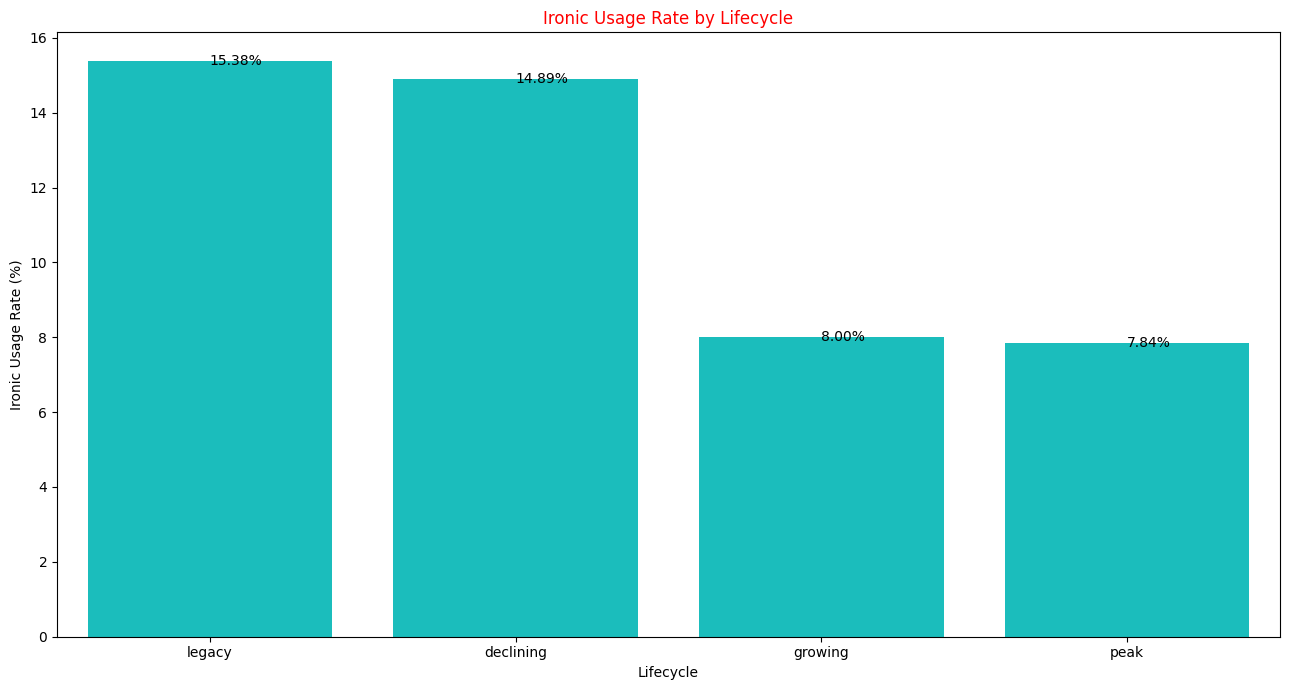

In [32]:
#Ironic Usage Rate by Lifecycle

ironic_by_phases = (Genz.groupby('lifecycle_phase')
['ironic_usage'].mean() * 100)
ironic_by_phases = (ironic_by_phases.reset_index().sort_values(by="ironic_usage",ascending=False))
plt.figure(figsize=(13,7))
ax = sns.barplot(x = "lifecycle_phase",y="ironic_usage",
data= ironic_by_phases,color="#00d8d6")
plt.ylabel("Ironic Usage Rate (%)")
plt.xlabel("Lifecycle")
plt.title("Ironic Usage Rate by Lifecycle",
fontsize = 12, color = "Red")
for i, v in enumerate(ironic_by_phases["ironic_usage"]):
    ax.text(i,v + 0.01, f'{v:.2f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

Insights
• Legacy slang has the highest ironic usage (~15.4%), showing older
terms are often reused sarcastically rather than seriously.
• Declining slang also shows high ironic usage (~14.9%), indicating users
shift to irony as trends fade.
• Growing slang has much lower ironic usage (~8%), meaning new terms
are mostly used sincerely.
• Peak-phase slang shows the lowest ironic usage (~7.8%), suggesting
maximum popularity aligns with genuine usage.

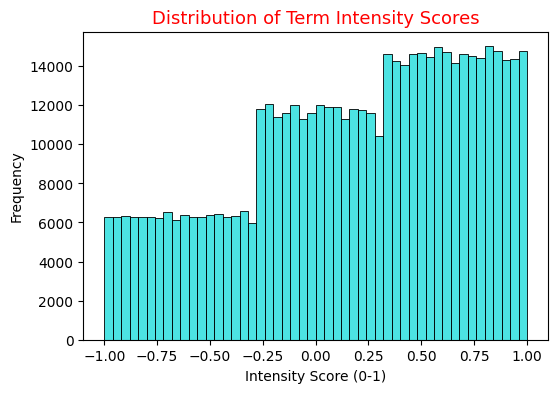

In [33]:
#Distribution of Intesity Score

plt.figure(figsize=(6,4))
sns.histplot(x = "sentiment_score", data=Genz,
bins=50, alpha=0.7, color="#00d8d6")
plt.title('Distribution of Term Intensity Scores',
fontsize=13, color ="red")
plt.xlabel('Intensity Score (0-1)')
plt.ylabel('Frequency')
plt.show()

Intensity scores are skewed toward the positive side, indicating most
slang terms are used with moderate to high emotional intensity.
• High-frequency peaks appear between 0.4 and 1.0, showing slang is
often used for strong expression or emphasis.
• Negative intensity values (−1 to −0.4) are less frequent, suggesting
fewer slang terms convey strong negativity.
• Mid-range intensity (around −0.2 to 0.3) shows stable usage, reflecting
casual or neutral slang expressions.

In [ ]:
Time Series Analysis

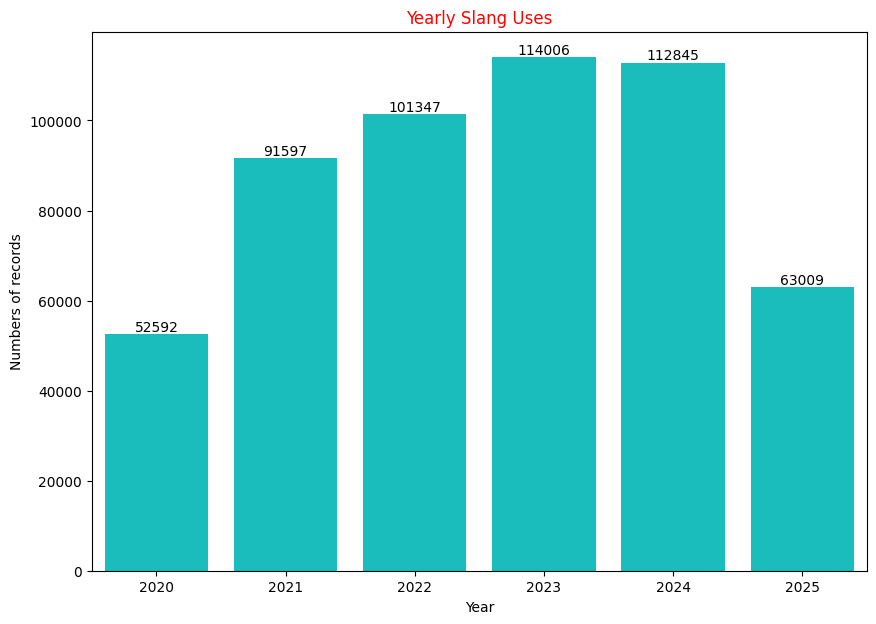

In [34]:
#Yearly Uses Slang

Yearly_Slang = (
Genz["timestamp"].dt.year.value_counts().reset_index())
plt.figure(figsize=(10,7))
ax = sns.barplot(x = "timestamp", y= "count",
data=Yearly_Slang, color="#00d8d6")
for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Yearly Slang Uses",
fontsize = 12, color = "Red")
plt.xlabel("Year")
plt.ylabel("Numbers of records")
plt.show()

Slang usage shows strong growth from 2020 to 2023, indicating rapid
adoption and expansion across digital platforms.
• 2023 is the peak year, with the highest number of slang records,
reflecting maximum cultural and social media influence.
• 2024 remains consistently high, showing that slang usage has
stabilized at a mature level.
• A noticeable drop appears in 2025, which likely indicates partial-year
data rather than an actual decline.
• The sharp increase after 2020 aligns with increased online activity and
social media engagement.

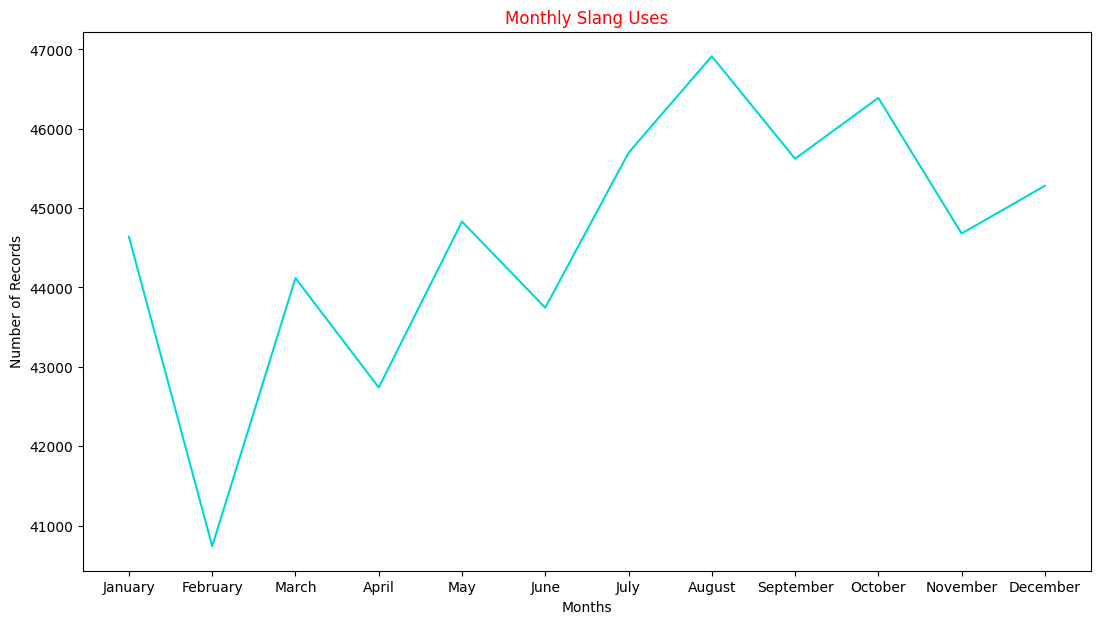

In [35]:
#Monthly Slang


Genz["Months"] = Genz["timestamp"].dt.month_name()
month_order = [
"January","February","March","April","May","June",
"July","August","September","October","November","December"
]
Monthly_Slang = Genz["Months"].value_counts().reset_index()
Monthly_Slang["Months"] = pd.Categorical(
Monthly_Slang["Months"],
categories=month_order,
ordered=True)
plt.figure(figsize=(13,7))
sns.lineplot(x = "Months", y = "count",
data=Monthly_Slang, color = "#00d8d6")
plt.title("Monthly Slang Uses",
fontsize = 12, color="red")
plt.xlabel("Months")
plt.ylabel("Number of Records")
plt.show()

• February shows the lowest slang usage, indicating a temporary dip in
online activity.
• A steady upward trend begins from March onward, showing increasing
engagement through the year.
• Peak usage occurs in August, suggesting maximum slang activityIn [73]:during mid-year.
• Post-August, usage remains relatively high, with only minor
fluctuations.
• December ends stronger than the start of the year, indicating sustained
interest rather than decline

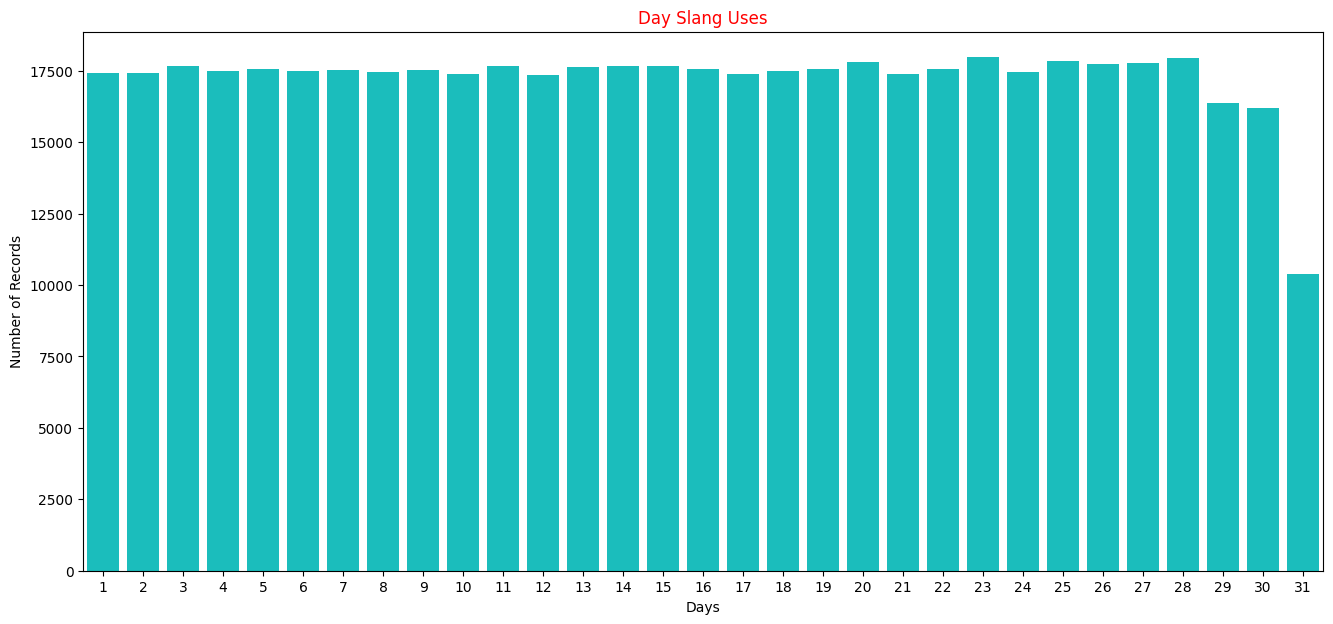

In [36]:

#Daily Slang 
Genz["Day"] = Genz["timestamp"].dt.day
Daily_Slang = (Genz["Day"].value_counts().reset_index().sort_values(by="Day"))
plt.figure(figsize=(16,7))
sns.barplot(x = "Day", y = "count",
data=Daily_Slang, color = "#00d8d6")
plt.title("Day Slang Uses",
fontsize = 12, color="red")
plt.xlabel("Days")
plt.ylabel("Number of Records")
plt.show()